# 02. EDA и предобработка данных

**Цель ноутбука:** провести исследовательский анализ, очистить данные
и подготовить признаки для ML-модели.

**Входные данные:** `../data/raw/drom_cars_4000.csv` (4006 строк, 17 колонок)

**Что делает ноутбук:**
- первичный анализ: типы, пропуски, аномалии
- очистка: удаление пустой колонки «кузов», исправление ошибок парсинга
- feature engineering: разбор «двигатель» на объём/топливо/ГБО,
  разбор «марка_модель» на марку и модель, унификация дублей (Лада/LADA,
  автомат/АКПП)
- статистический анализ: распределения, корреляции, проверка гипотез
- визуализации: гистограммы, boxplot, тепловые карты, scatter-plot

**Результат:** `../data/processed/cars_clean.csv` — 4006 строк, 21 колонка

**Следующий этап:** `03_ML_model.ipynb` — построение ML-модели

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_name = "../data/raw/drom_cars_4000.csv" 
df = pd.read_csv(file_name)

print("Всего записей:", len(df))
print("Колонки:", df.columns.tolist())

Всего записей: 4006
Колонки: ['url', 'ad_id', 'марка_модель', 'цена', 'год', 'двигатель', 'мощность', 'коробка', 'привод', 'цвет', 'пробег', 'владельцы', 'руль', 'поколение', 'комплектация', 'город', 'кузов']


In [3]:
df.head()

,url,ad_id,марка_модель,цена,год,двигатель,мощность,коробка,привод,цвет,пробег,владельцы,руль,поколение,комплектация,город,кузов
0,https://auto.drom.ru/moscow/bmw/x5/830642681.html,830642681,БМВ Х5,5497000,2020,"дизель, 2.0 л",231.0,АКПП,4WD,синий,109 705,1.0,левый,4 поколение,xDrive 25d AT Business,Москва,NaN
1,https://auto.drom.ru/moscow/mercedes-benz/gle-...,452207340,Мерседес ГЛЕ-Класс,8700000,2021,"дизель, 2.9 л",330.0,АКПП,4WD,черный,69 000,2.0,левый,2 поколение,GLE 400 d 4MATIC Sport,Москва,NaN
2,https://auto.drom.ru/moscow/honda/accord/53254...,532545962,Хонда Аккорд,950000,2008,"бензин, 2.4 л",201.0,АКПП,передний,серый,266 000,NaN,левый,8 поколение,2.4 AT Executive,Москва,NaN
3,https://auto.drom.ru/moscow/ssang_yong/kyron/3...,331134404,СсангЙонг Кайрон,449000,2008,"дизель, 2.0 л",141.0,АКПП,4WD,фиолетовый,205 195,NaN,левый,"1 поколение, рестайлинг",2.0 Xdi AT 4WD Luxury,Москва,NaN
4,https://auto.drom.ru/moscow/skoda/octavia/5467...,546771991,Шкода Октавия,599000,2009,"бензин, 1.8 л",152.0,робот,передний,красный,150 164,2.0,левый,"2 поколение, рестайлинг",NaN,Москва,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4006 entries, 0 to 4005
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   url           4006 non-null   object 
 1   ad_id         4006 non-null   int64  
 2   марка_модель  4006 non-null   object 
 3   цена          4006 non-null   int64  
 4   год           4006 non-null   int64  
 5   двигатель     4000 non-null   object 
 6   мощность      3993 non-null   float64
 7   коробка       3999 non-null   object 
 8   привод        3996 non-null   object 
 9   цвет          3911 non-null   object 
 10  пробег        3840 non-null   object 
 11  владельцы     2599 non-null   float64
 12  руль          3917 non-null   object 
 13  поколение     3938 non-null   object 
 14  комплектация  2616 non-null   object 
 15  город         3945 non-null   object 
 16  кузов         0 non-null      float64
dtypes: float64(3), int64(3), object(11)
memory usage: 532.2+ KB


In [5]:
df.describe()

,ad_id,цена,год,мощность,владельцы,кузов
count,4.006000e+03,4.006000e+03,4006.000000,3993.000000,2599.000000,0.0
mean,5.695071e+08,1.747324e+06,2012.943335,153.984222,1.932282,NaN
std,2.523973e+08,2.249061e+06,7.207434,74.097851,0.825890,NaN
min,3.929758e+07,1.000000e+04,1975.000000,46.000000,1.000000,NaN
25%,3.509849e+08,5.998325e+05,2008.000000,105.000000,1.000000,NaN
50%,5.900080e+08,1.113500e+06,2013.000000,140.000000,2.000000,NaN
75%,7.974672e+08,1.950000e+06,2019.000000,177.000000,3.000000,NaN
max,9.497605e+08,3.340000e+07,2026.000000,612.000000,3.000000,NaN


In [6]:
df.describe(include='object')

,url,марка_модель,двигатель,коробка,привод,цвет,пробег,руль,поколение,комплектация,город
count,4006,4006,4000,3999,3996,3911,3840,3917,3938,2616,3945
unique,4006,177,105,5,3,16,1919,2,36,1528,548
top,https://auto.drom.ru/vladivostok/honda/odyssey...,Тойота Ленд Крузер Прадо,"бензин, 1.6 л",АКПП,передний,белый,200 000,левый,1 поколение,1.6 MT Comfort,Москва
freq,1,48,1002,1794,2331,979,67,3205,1034,33,308


In [7]:
df.isnull().sum()

url                0
ad_id              0
марка_модель       0
цена               0
год                0
двигатель          6
мощность          13
коробка            7
привод            10
цвет              95
пробег           166
владельцы       1407
руль              89
поколение         68
комплектация    1390
город             61
кузов           4006
dtype: int64

In [8]:
""" В файле отс-т информация по кузову, ее не удалось спарсить, поэтому я решил
удалить этот столбец"""

df = df.drop('кузов', axis=1)
df.isnull().sum()

url                0
ad_id              0
марка_модель       0
цена               0
год                0
двигатель          6
мощность          13
коробка            7
привод            10
цвет              95
пробег           166
владельцы       1407
руль              89
поколение         68
комплектация    1390
город             61
dtype: int64

In [14]:
# Предобработка данных
# 1. Нормализация строкового формата
df['пробег'] = pd.to_numeric(
    df['пробег'].astype(str).str.replace(r'\s+', '', regex=True),
    errors='coerce'
)

# 2. Приведение числовых колонок к единому типу
for col in ['цена', 'год', 'мощность', 'владельцы']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Объём двигателя — число перед "л"
df['объём'] = pd.to_numeric(
    df['двигатель']
      .str.extract(r'(\d+[.,]?\d*)\s*л')[0]
      .str.replace(',', '.', regex=False),
    errors='coerce'
)

# 4. Тип топлива (порядок проверок: специфичные первыми!)
def extract_fuel(x):
    x = str(x).lower()
    if 'электро' in x: return 'Электро'
    if 'гибрид'  in x: return 'Гибрид'
    if 'дизель'  in x: return 'Дизель'
    if 'бензин'  in x: return 'Бензин'
    if x in ('неизвестно', 'nan'): return 'Неизвестно'
    if 'л' in x: return 'Бензин'   # указан только объём → бензин
    return 'Другое'

df['топливо'] = df['двигатель'].apply(extract_fuel)

# 5. Газобаллонное оборудование
df['гбо'] = df['двигатель'].str.contains('ГБО', case=False, na=False)

In [15]:
print("Типы:")
print(df[['пробег', 'цена', 'год', 'мощность', 'владельцы', 'объём']].dtypes)

print("\nТопливо:")
print(df['топливо'].value_counts())

print("\nЧто в 'Другое' (первые 20):")
print(df[df['топливо'] == 'Другое']['двигатель'].value_counts().head(20))

print(f"\nОбъём: медиана {df['объём'].median()}, пропусков {df['объём'].isna().sum()}")
print(f"ГБО: {df['гбо'].sum()} шт.")

print("\nПервые строки:")
print(df[['двигатель', 'объём', 'топливо', 'гбо']].head(10))

Типы:
пробег       float64
цена           int64
год            int64
мощность     float64
владельцы    float64
объём        float64
dtype: object

Топливо:
топливо
Бензин        3444
Дизель         332
Гибрид         184
Электро         40
Неизвестно       6
Name: count, dtype: int64

Что в 'Другое' (первые 20):
Series([], Name: count, dtype: int64)

Объём: медиана 1.8, пропусков 48
ГБО: 120 шт.

Первые строки:
               двигатель  объём топливо    гбо
0          дизель, 2.0 л    2.0  Дизель  False
1          дизель, 2.9 л    2.9  Дизель  False
2          бензин, 2.4 л    2.4  Бензин  False
3          дизель, 2.0 л    2.0  Дизель  False
4          бензин, 1.8 л    1.8  Бензин  False
5          бензин, 2.0 л    2.0  Бензин  False
6  бензин, 1.5 л, гибрид    1.5  Гибрид  False
7          бензин, 1.5 л    1.5  Бензин  False
8          бензин, 3.4 л    3.4  Бензин  False
9          бензин, 2.0 л    2.0  Бензин  False


In [18]:
# --- Проверка пропусков ---
print("=" * 60)
print("ПРОПУСКИ")
print("=" * 60)
miss = df[['пробег', 'цена', 'год', 'мощность', 'владельцы', 'объём']].isna().sum()
miss_pct = (miss / len(df) * 100).round(2)
print(pd.DataFrame({'пропуски': miss, '%': miss_pct}))

# --- Пробег: аномалии ---
print("=" * 60)
print("ПРОБЕГ")
print("=" * 60)
print(df['пробег'].describe())
print(f"\nПробег < 100 км:      {(df['пробег'] < 100).sum()}")
print(f"Пробег > 500 000 км:  {(df['пробег'] > 500_000).sum()}")
print(f"Пробег == 0:          {(df['пробег'] == 0).sum()}")

# --- Цена: аномалии ---
print("=" * 60)
print("ЦЕНА")
print("=" * 60)
print(df['цена'].describe())
print(f"\nЦена < 50 000:        {(df['цена'] < 50_000).sum()}")
print(f"Цена > 15 000 000:    {(df['цена'] > 15_000_000).sum()}")

# --- Год: аномалии ---
print("=" * 60)
print("ГОД")
print("=" * 60)
print(df['год'].value_counts().sort_index().tail(10))
print(f"Год < 1990:           {(df['год'] < 1990).sum()}")
print(f"Год > 2026:           {(df['год'] > 2026).sum()}")

# --- Мощность: аномалии ---
print("=" * 60)
print("МОЩНОСТЬ")
print("=" * 60)
print(df['мощность'].describe())
print(f"Мощность < 30 л.с.:   {(df['мощность'] < 30).sum()}")
print(f"Мощность > 600 л.с.:  {(df['мощность'] > 600).sum()}")

# --- Владельцы ---
print("=" * 60)
print("ВЛАДЕЛЬЦЫ")
print("=" * 60)
print(df['владельцы'].value_counts(dropna=False).sort_index())
print(f"Пропусков: {df['владельцы'].isna().sum()} ({df['владельцы'].isna().mean()*100:.1f}%)")

ПРОПУСКИ
           пропуски      %
пробег          166   4.14
цена              0   0.00
год               0   0.00
мощность         13   0.32
владельцы      1407  35.12
объём            48   1.20
ПРОБЕГ
count      3840.000000
mean     173508.877604
std       99590.469306
min           1.000000
25%       99000.000000
50%      164309.000000
75%      233008.250000
max      888888.000000
Name: пробег, dtype: float64

Пробег < 100 км:      37
Пробег > 500 000 км:  17
Пробег == 0:          0
ЦЕНА
count    4.006000e+03
mean     1.747324e+06
std      2.249061e+06
min      1.000000e+04
25%      5.998325e+05
50%      1.113500e+06
75%      1.950000e+06
max      3.340000e+07
Name: цена, dtype: float64

Цена < 50 000:        7
Цена > 15 000 000:    31
ГОД
год
2017    170
2018    234
2019    240
2020    223
2021    208
2022     81
2023     52
2024     29
2025     41
2026    145
Name: count, dtype: int64
Год < 1990:           18
Год > 2026:           0
МОЩНОСТЬ
count    3993.000000
mean      153.98

In [19]:
# Чистка аномалий

# Пробег < 100 км у машин старше 2020 — ошибка ввода
mask = (df['пробег'] < 100) & (df['год'] < 2020)
print(f"Пробег < 100 км у старых: {mask.sum()} → NaN")
df.loc[mask, 'пробег'] = np.nan

# Пробег > 800 000 км — мусор
mask = df['пробег'] > 800_000
print(f"Пробег > 800 000 км: {mask.sum()} → NaN")
df.loc[mask, 'пробег'] = np.nan

Пробег < 100 км у старых: 7 → NaN
Пробег > 800 000 км: 2 → NaN


In [21]:
# Инженерия признаков из марка_модель

# Марка — первое слово 
df['марка'] = df['марка_модель'].str.split().str[0]

# Унификация явных дублей в марке
df['марка'] = df['марка'].replace({
    'Лада': 'LADA',
    'Ленд': 'Ленд Ровер',
})

# Модель — всё, что после первого слова
#   Оставляю модель целиком,
#   пример: БМВ Х3 и БМВ Х5 — разные машины с разной ценой
df['модель'] = df['марка_модель'].str.split(n=1).str[1]

# Проверка результата
print(f"Уникальных марок:   {df['марка'].nunique()}")
print(f"Уникальных моделей: {df['модель'].nunique()}")

print("\nТоп-15 марок:")
print(df['марка'].value_counts().head(15))

print("\nТоп-15 моделей:")
print(df['марка_модель'].value_counts().head(15))

print("\nПримеры разбора:")
print(df[['марка_модель', 'марка', 'модель']].sample(15, random_state=42))

Уникальных марок:   39
Уникальных моделей: 177

Топ-15 марок:
марка
Тойота         565
LADA           443
Ниссан         422
Хендай         405
Киа            347
Рено           266
Хонда          231
БМВ            223
Ауди           184
Фольксваген    167
Шкода          166
Мицубиси       128
Субару         102
Мазда           87
Сузуки          81
Name: count, dtype: int64

Топ-15 моделей:
марка_модель
Тойота Ленд Крузер Прадо    48
Мазда Мазда 3               45
LADA Granta                 44
Лада 2115 Самара            44
Хендай Ай Икс 35            43
Хонда Аккорд                43
LADA Vesta                  42
Хендай Крета                42
Тойота Ленд Крузер          42
Ниссан Ноут                 42
LADA XRAY                   42
Тойота Королла              42
Ниссан Мурано               42
Хендай Элантра              42
Хендай Санта Фе             41
Name: count, dtype: int64

Примеры разбора:
            марка_модель        марка     модель
761           Киа Церато         

In [23]:
# Проверка: где модель начинается с марки
df['марка_в_модели'] = df.apply(
    lambda row: str(row['модель']).startswith(str(row['марка']) + ' '),
    axis=1
)

print(f"Строк, где модель дублирует марку: {df['марка_в_модели'].sum()}")
print("\nПримеры:")
print(df[df['марка_в_модели']][['марка_модель', 'марка', 'модель']].head(20))

Строк, где модель дублирует марку: 86

Примеры:
       марка_модель  марка   модель
19    Мазда Мазда 3  Мазда  Мазда 3
1357  Мазда Мазда 3  Мазда  Мазда 3
1358  Мазда Мазда 3  Мазда  Мазда 3
1359  Мазда Мазда 3  Мазда  Мазда 3
1360  Мазда Мазда 3  Мазда  Мазда 3
1361  Мазда Мазда 3  Мазда  Мазда 3
1362  Мазда Мазда 3  Мазда  Мазда 3
1363  Мазда Мазда 3  Мазда  Мазда 3
1364  Мазда Мазда 3  Мазда  Мазда 3
1365  Мазда Мазда 3  Мазда  Мазда 3
1366  Мазда Мазда 3  Мазда  Мазда 3
1367  Мазда Мазда 3  Мазда  Мазда 3
1368  Мазда Мазда 3  Мазда  Мазда 3
1369  Мазда Мазда 3  Мазда  Мазда 3
1370  Мазда Мазда 3  Мазда  Мазда 3
1371  Мазда Мазда 3  Мазда  Мазда 3
1372  Мазда Мазда 3  Мазда  Мазда 3
1373  Мазда Мазда 3  Мазда  Мазда 3
1374  Мазда Мазда 3  Мазда  Мазда 3
1375  Мазда Мазда 3  Мазда  Мазда 3


In [24]:
# Смотрим все уникальные проблемные строки
problem_rows = df[df['марка_в_модели']][['марка_модель', 'марка', 'модель']]

print("Уникальные проблемные строки:")
print(problem_rows.drop_duplicates().to_string())

Уникальные проблемные строки:
       марка_модель  марка   модель
19    Мазда Мазда 3  Мазда  Мазда 3
1380  Мазда Мазда 6  Мазда  Мазда 6


In [25]:
# Чистим дубли: где модель начинается с марки — убираем марку из начала
mask = df['марка_в_модели']

df.loc[mask, 'марка_модель'] = (
    df.loc[mask, 'марка'] + ' ' +
    df.loc[mask, 'модель'].str.replace(
        df.loc[mask, 'марка'] + ' ', '', n=1, regex=False
    )
)

# Пересобираем модель из почищенной марка_модель
df['модель'] = df['марка_модель'].str.split(n=1).str[1]

# Убираем вспомогательный столбец
df = df.drop(columns=['марка_в_модели'])

# Проверка
print("Проверка — Мазда:")
print(df[df['марка'] == 'Мазда'][['марка_модель', 'марка', 'модель']].drop_duplicates().to_string())

print(f"\nУникальных моделей: {df['модель'].nunique()}")
print(f"Всего Мазда: {(df['марка'] == 'Мазда').sum()}")

Проверка — Мазда:
    марка_модель  марка  модель
19           NaN  Мазда     NaN
84  Мазда Аксела  Мазда  Аксела

Уникальных моделей: 175
Всего Мазда: 87


In [26]:
print("Пропусков в марка_модель:", df['марка_модель'].isna().sum())
print("\nУ каких марок пропуски:")
print(df[df['марка_модель'].isna()]['марка'].value_counts())

Пропусков в марка_модель: 86

У каких марок пропуски:
марка
Мазда    86
Name: count, dtype: int64


In [27]:
# Смотрим url сломанных строк
broken = df[df['марка_модель'].isna()]
print("Примеры url сломанных Мазд:")
print(broken['url'].head(20).to_string())

# И смотрим, какие модели у целых Мазд (тех, что не сломались)
ok_mazda = df[(df['марка'] == 'Мазда') & (df['марка_модель'].notna())]
print("\nМодели целых Мазд:")
print(ok_mazda['модель'].value_counts())

Примеры url сломанных Мазд:
19      https://auto.drom.ru/moscow/mazda/mazda3/33528...
1357    https://auto.drom.ru/omsk/mazda/mazda3/1238405...
1358    https://auto.drom.ru/barnaul/mazda/mazda3/7312...
1359    https://auto.drom.ru/surgut/mazda/mazda3/44472...
1360    https://auto.drom.ru/togliatti/mazda/mazda3/26...
1361    https://auto.drom.ru/krasnoyarsk/mazda/mazda3/...
1362    https://auto.drom.ru/krasnodar/mazda/mazda3/90...
1363    https://auto.drom.ru/sredniy/mazda/mazda3/2130...
1364    https://auto.drom.ru/naberezhnye-chelny/mazda/...
1365    https://auto.drom.ru/novosibirsk/mazda/mazda3/...
1366    https://auto.drom.ru/surgut/mazda/mazda3/54520...
1367    https://auto.drom.ru/kurgan/mazda/mazda3/75775...
1368    https://auto.drom.ru/novosibirsk/mazda/mazda3/...
1369    https://auto.drom.ru/anapa/mazda/mazda3/860589...
1370    https://auto.drom.ru/pavlovskaya/mazda/mazda3/...
1371    https://auto.drom.ru/barnaul/mazda/mazda3/5216...
1372    https://auto.drom.ru/kemerovo/mazda/

In [28]:
# Восстанавливаем марка_модель для сломанных Мазд
# Все 86 строк — это Mazda 3 (в url всегда mazda3)
mask = df['марка_модель'].isna() & (df['марка'] == 'Мазда')

df.loc[mask, 'марка_модель'] = 'Мазда 3'
df.loc[mask, 'модель']      = '3'

print(f"Восстановлено: {mask.sum()} строк")

# Проверка
print("\nВсе Мазды теперь:")
print(df[df['марка'] == 'Мазда'][['марка_модель', 'марка', 'модель']].value_counts().to_string())

print(f"\nПропусков в марка_модель: {df['марка_модель'].isna().sum()}")
print(f"Всего Мазда: {(df['марка'] == 'Мазда').sum()}")

Восстановлено: 86 строк

Все Мазды теперь:
марка_модель  марка  модель
Мазда 3       Мазда  3         86
Мазда Аксела  Мазда  Аксела     1

Пропусков в марка_модель: 0
Всего Мазда: 87


In [29]:
df_backup = df.copy()
print("Бэкап сохранён")

Бэкап сохранён


Статистика цены:
count         4,006
mean      1,747,324
std       2,249,061
min          10,000
25%         599,832
50%       1,113,500
75%       1,950,000
max      33,400,000
Name: цена, dtype: object

Медиана: 1,113,500
Среднее: 1,747,324


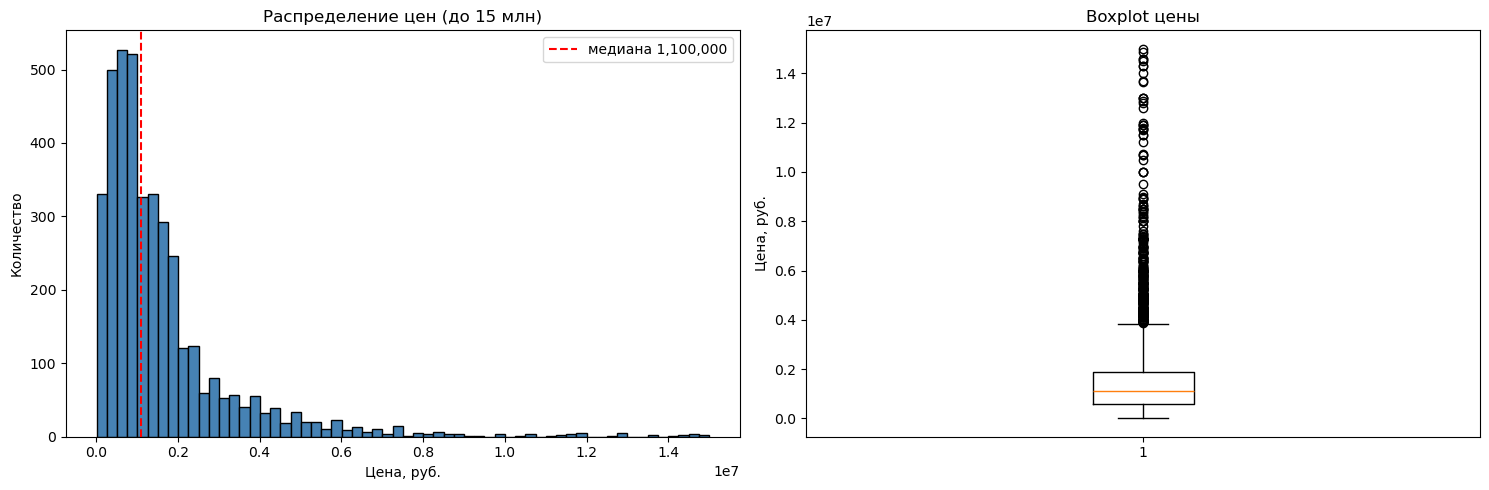

In [30]:
# Распределение цены

# Базовая статистика
print("Статистика цены:")
print(df['цена'].describe().apply(lambda x: f"{x:,.0f}"))

print(f"\nМедиана: {df['цена'].median():,.0f}")
print(f"Среднее: {df['цена'].mean():,.0f}")

# Гистограмма + boxplot рядом
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Гистограмма (до 15 млн — чтобы мусор не портил картинку)
prices = df[df['цена'] < 15_000_000]['цена']
axes[0].hist(prices, bins=60, color='steelblue', edgecolor='black')
axes[0].axvline(prices.median(), color='red', linestyle='--',
                label=f'медиана {prices.median():,.0f}')
axes[0].set_title('Распределение цен (до 15 млн)')
axes[0].set_xlabel('Цена, руб.')
axes[0].set_ylabel('Количество')
axes[0].legend()

# Boxplot — выбросы
axes[1].boxplot(prices, vert=True)
axes[1].set_title('Boxplot цены')
axes[1].set_ylabel('Цена, руб.')

plt.tight_layout()
plt.show()

"""
Из графиков можно сделать следующие выводы

1. Размер выборки: 4006 машин, пропусков в цене нет.

2. Основные числа:
  - Минимум:  10 000 ₽ (старая LADA или битая)
  - Q1:      600 000 ₽ (25% машин дешевле)
  - Медиана: 1 113 500 ₽ (типичная машина)
  - Q3:      1 950 000 ₽ (75% машин дешевле)
  - Максимум: 33 400 000 ₽ (Лексус LX / Мерседес S)
  - Среднее: 1 747 324 ₽

3. Среднее (1.75 млн) больше медианы (1.11 млн) в 1.6 раза.
   Это значит: распределение скошено вправо — есть длинный
   хвост из дорогих машин, которые тянут среднее вверх.

4. Гистограмма подтверждает: основная масса машин до 2-3 млн,
   дальше длинный редкий хвост.

5. Boxplot показал много выбросов сверху — но это не ошибки,
   это реальные дорогие машины (БМВ, Мерседес, Лексус).

6. Так как цена распределена не нормально (скошена вправо),
   для будущей ML-модели:
   - CatBoost сам справится, трансформация не нужна
   - Метрику лучше брать MAE (устойчивее к выбросам, чем RMSE)
"""

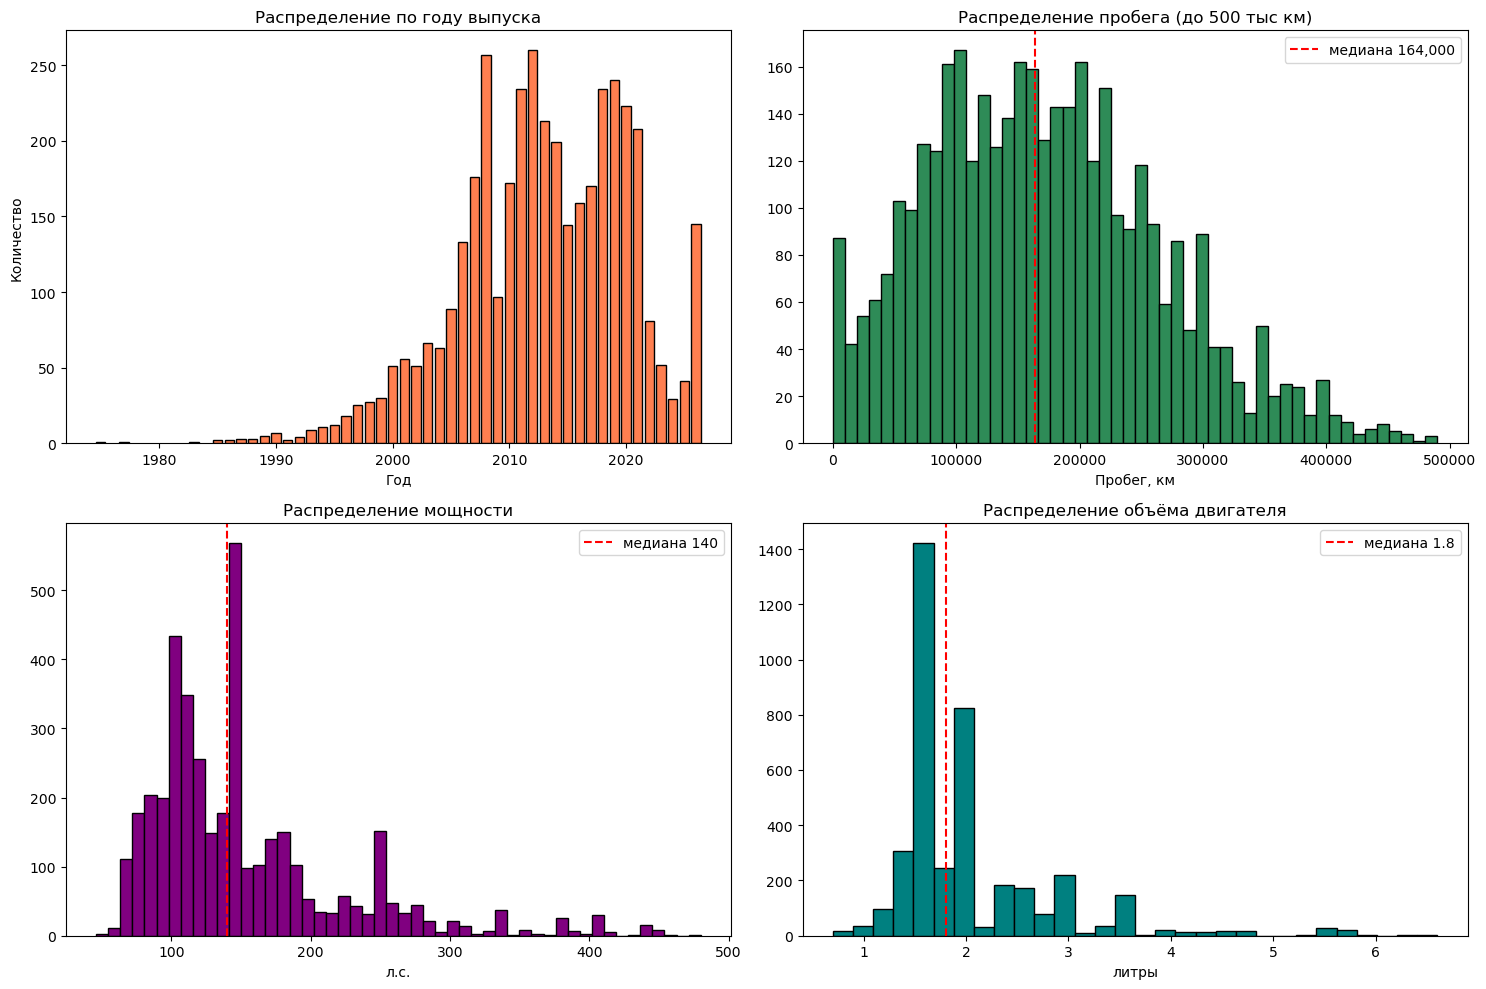

Статистика числовых признаков:
          год    пробег  мощность   объём
count  4006.0    3831.0    3993.0  3958.0
mean   2012.9  173461.0     154.0     2.0
std       7.2   98139.3      74.1     0.8
min    1975.0       1.0      46.0     0.7
25%    2008.0   99426.0     105.0     1.6
50%    2013.0  164900.0     140.0     1.8
75%    2019.0  233016.5     177.0     2.2
max    2026.0  700000.0     612.0     6.6


In [31]:
# Распределение числовых признаков

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Год выпуска
ax = axes[0, 0]
year_counts = df['год'].value_counts().sort_index()
ax.bar(year_counts.index, year_counts.values, color='coral', edgecolor='black')
ax.set_title('Распределение по году выпуска')
ax.set_xlabel('Год')
ax.set_ylabel('Количество')

# 2. Пробег (до 500 тыс, чтобы хвост не портил картинку)
ax = axes[0, 1]
mileage = df[(df['пробег'] > 0) & (df['пробег'] < 500_000)]['пробег']
ax.hist(mileage, bins=50, color='seagreen', edgecolor='black')
ax.axvline(mileage.median(), color='red', linestyle='--',
           label=f'медиана {mileage.median():,.0f}')
ax.set_title('Распределение пробега (до 500 тыс км)')
ax.set_xlabel('Пробег, км')
ax.legend()

# 3. Мощность
ax = axes[1, 0]
power = df[(df['мощность'] > 0) & (df['мощность'] < 500)]['мощность']
ax.hist(power, bins=50, color='purple', edgecolor='black')
ax.axvline(power.median(), color='red', linestyle='--',
           label=f'медиана {power.median():,.0f}')
ax.set_title('Распределение мощности')
ax.set_xlabel('л.с.')
ax.legend()

# 4. Объём двигателя
ax = axes[1, 1]
volume = df[df['объём'].notna()]['объём']
ax.hist(volume, bins=30, color='teal', edgecolor='black')
ax.axvline(volume.median(), color='red', linestyle='--',
           label=f'медиана {volume.median():.1f}')
ax.set_title('Распределение объёма двигателя')
ax.set_xlabel('литры')
ax.legend()

plt.tight_layout()
plt.show()

# Текстовая статистика
print("Статистика числовых признаков:")
print(df[['год', 'пробег', 'мощность', 'объём']].describe().round(1))

Из графиков можно сделать следующие выводы

1. ГОД ВЫПУСКА
   - Диапазон: 1975–2026, медиана 2013
   - Основная масса: 2005–2021
   - Есть пик на 2024–2026 (145 машин) — вероятно, машины
     «под заказ» или нестандартный год
   - Старых машин (< 2000) мало — единицы

2. ПРОБЕГ
   - Медиана 164 900 км, среднее 173 461 — почти совпадают, скос слабый
   - Основная масса: 50–300 тыс км
   - Пропусков 166 (после чистки), это 4%
   - Есть машины с пробегом < 100 км (реально новые) — не удалял

3. МОЩНОСТЬ
   - Диапазон: 46–612 л.с., медиана 140
   - Два пика: ~110 л.с. (бюджет) и ~150 л.с. (средний сегмент)
   - Длинный хвост до 600+ (спорткары: BMW M, Mercedes AMG)
   - Std = 74 — разброс умеренный

4. ОБЪЁМ ДВИГАТЕЛЯ
   - Диапазон: 0.7–6.6 л, медиана 1.8
   - Главные пики: 1.6 л и 2.0 л (это больше половины рынка)
   - Есть японские kei-car (0.7 л) и премиум (5.7–6.6 л)
   - Пропусков 48 (это электромобили + Неизвестно)

5. ВЫВОД ДЛЯ ML:
   - Числовые признаки распределены скошено вправо (пробег,
     мощность) — но не критично, CatBoost справится
   - Пропуски есть в пробеге (4%) и объёме (1.2%)

In [34]:
# Объединяем дубль: "автомат" и "АКПП" — это одно и то же
df['коробка'] = df['коробка'].replace({'автомат': 'АКПП'})

print(df['коробка'].value_counts())

коробка
АКПП          1879
механика      1141
вариатор       692
робот          287
неизвестно       7
Name: count, dtype: int64


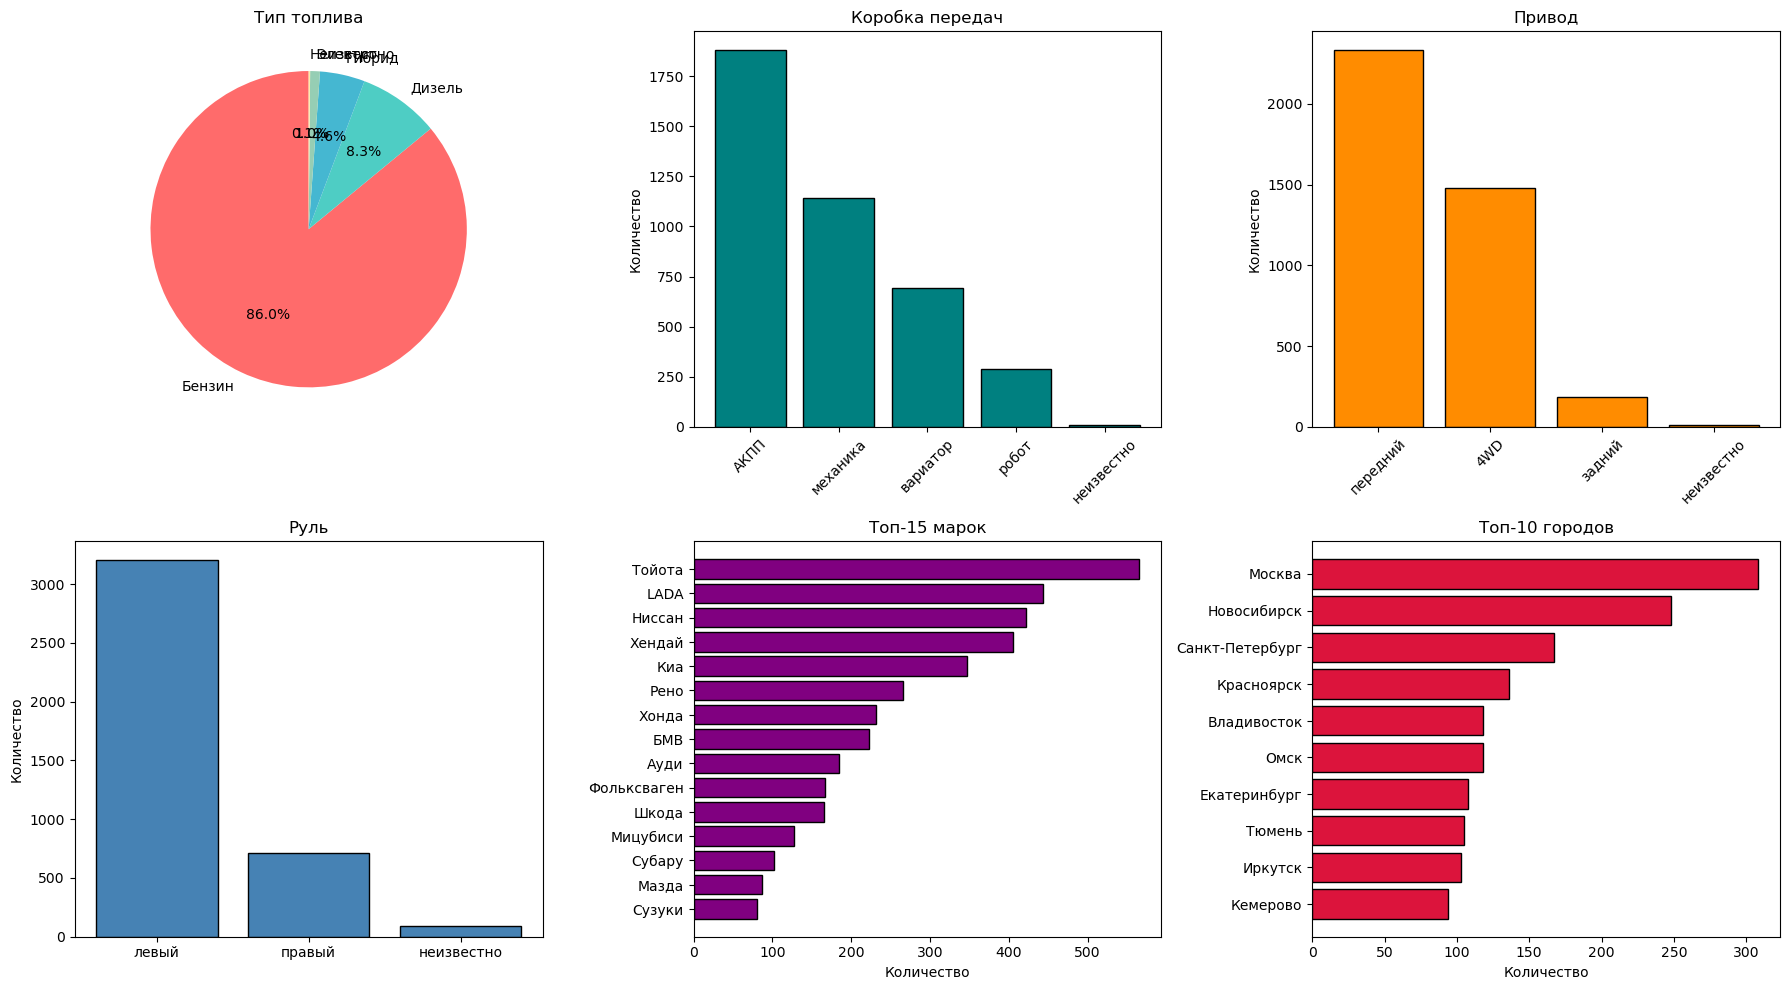


Категориальные признаки


[топливо]
топливо
Бензин        3444
Дизель         332
Гибрид         184
Электро         40
Неизвестно       6
Name: count, dtype: int64

[коробка]
коробка
АКПП          1879
механика      1141
вариатор       692
робот          287
неизвестно       7
Name: count, dtype: int64

[привод]
привод
передний      2331
4WD           1479
задний         186
неизвестно      10
Name: count, dtype: int64

[руль]
руль
левый         3205
правый         712
неизвестно      89
Name: count, dtype: int64

[Топ-15 марок]
марка
Тойота         565
LADA           443
Ниссан         422
Хендай         405
Киа            347
Рено           266
Хонда          231
БМВ            223
Ауди           184
Фольксваген    167
Шкода          166
Мицубиси       128
Субару         102
Мазда           87
Сузуки          81
Name: count, dtype: int64

[Топ-10 городов]
город
Москва             308
Новосибирск        248
Санкт-Петербург    167
Красноярск         136
Владивосток        118
Омск   

In [35]:
# Распределение категориальных признаков

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Тип топлива
ax = axes[0, 0]
fuel_counts = df['топливо'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
ax.pie(fuel_counts.values, labels=fuel_counts.index,
       autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Тип топлива')

# 2. Коробка передач
ax = axes[0, 1]
trans_counts = df['коробка'].value_counts()
ax.bar(trans_counts.index, trans_counts.values, color='teal', edgecolor='black')
ax.set_title('Коробка передач')
ax.set_ylabel('Количество')
ax.tick_params(axis='x', rotation=45)

# 3. Привод
ax = axes[0, 2]
drive_counts = df['привод'].value_counts()
ax.bar(drive_counts.index, drive_counts.values, color='darkorange', edgecolor='black')
ax.set_title('Привод')
ax.set_ylabel('Количество')
ax.tick_params(axis='x', rotation=45)

# 4. Руль
ax = axes[1, 0]
steer_counts = df['руль'].value_counts()
ax.bar(steer_counts.index, steer_counts.values, color='steelblue', edgecolor='black')
ax.set_title('Руль')
ax.set_ylabel('Количество')

# 5. Топ-15 марок
ax = axes[1, 1]
top_brands = df['марка'].value_counts().head(15)
ax.barh(top_brands.index[::-1], top_brands.values[::-1],
        color='purple', edgecolor='black')
ax.set_title('Топ-15 марок')
ax.set_xlabel('Количество')

# 6. Топ-10 городов
ax = axes[1, 2]
top_cities = df['город'].value_counts().head(10)
ax.barh(top_cities.index[::-1], top_cities.values[::-1],
        color='crimson', edgecolor='black')
ax.set_title('Топ-10 городов')
ax.set_xlabel('Количество')

plt.tight_layout()
plt.show()

# Текстовая сводка
print()
print("Категориальные признаки")
print()

for col in ['топливо', 'коробка', 'привод', 'руль']:
    print(f"\n[{col}]")
    print(df[col].value_counts(dropna=False))

print("\n[Топ-15 марок]")
print(df['марка'].value_counts().head(15))

print("\n[Топ-10 городов]")
print(df['город'].value_counts().head(10))

"""
Из графиков можно сделать следующие выводы

1. ТОПЛИВО
   - Бензин преобладает: 86% (3444 машины)
   - Дизель: 8.3% (332) — в основном внедорожники и премиум
   - Гибрид: 4.6% (184) — японцы (Toyota Prius, Lexus)
   - Электро: 1% (40) — Nissan Leaf и подобные
   - Неизвестно: 6 машин

2. КОРОБКА ПЕРЕДАЧ (после объединения "автомат" → "АКПП")
   - АКПП: 1879 (47%) — доминирует
   - Механика: 1141 (28%) — неожиданно много, в основном LADA
   - Вариатор: 692 (17%) — японцы и китайцы
   - Робот: 287 (7%) — DSG, Powershift
   - Неизвестно: 7 

3. ПРИВОД
   - Передний: 58% (2331) — доминирует (бюджет, город)
   - 4WD: 37% (1479) — внедорожники, кроссоверы
   - Задний: 5% (186) — BMW, Mercedes, классика

4. РУЛЬ
   - Левый: 80% (3205) — стандарт
   - Правый: 18% (712) — японский импорт (Приморье, Сибирь)
   - Неизвестно: 89

5. ТОП-5 МАРОК
   - Тойота (565), LADA (443), Ниссан (422), Хендай (405), Киа (347)
   - Ауди, БМВ, Мерседес — в топ-15, премиум-сегмент есть
   - LADA на 2 месте — думаю что это специфика российского рынка

6. ГЕОГРАФИЯ
   - Москва лидирует (308), но не доминирует (7.7%)
   - Новосибирск на 2 месте (248) — вероятно, восточная специфика
   - 10 городов покрывают ~33% данных
   - География смещена на восток (Сибирь, Дальний Восток)

7. Вывод для будущей модели:
   - Категориальные признаки чистые, дубль "автомат"/"АКПП" устранён
   - Пропусков мало (0.15–2%) — CatBoost обработает
   - "Правый руль" и "4WD" — важные сигналы для цены
"""

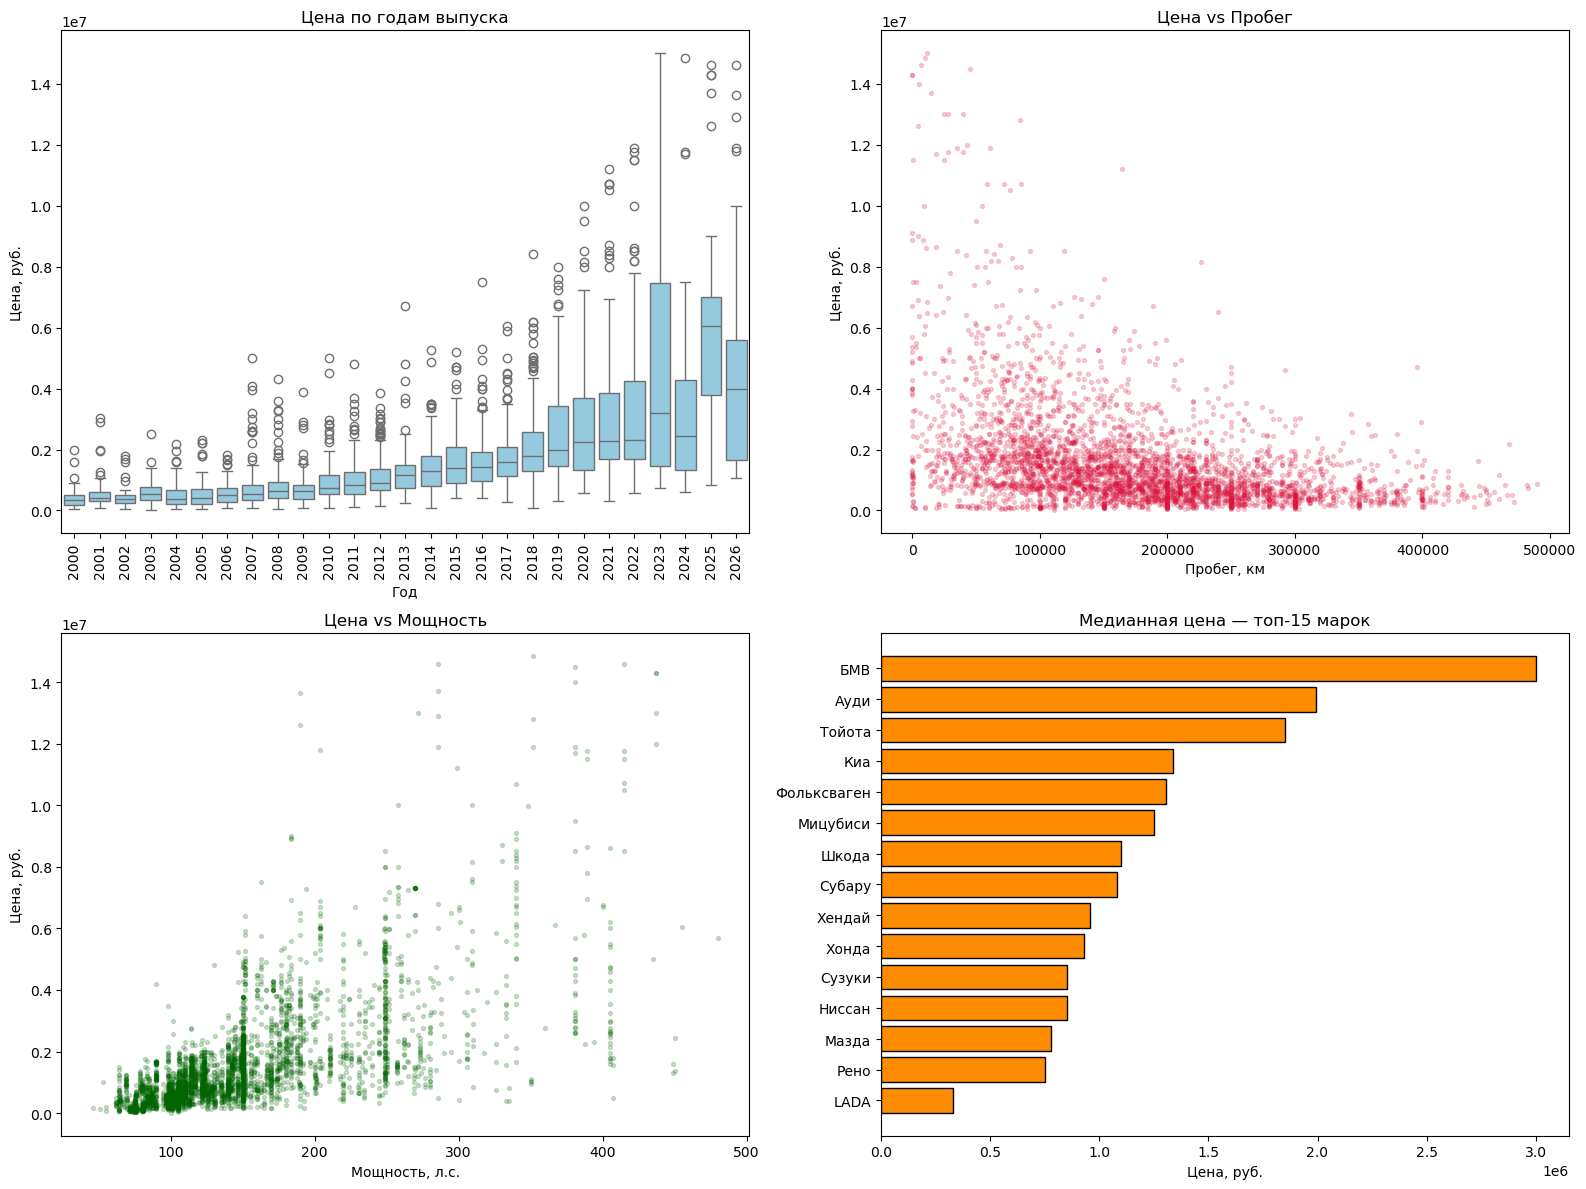

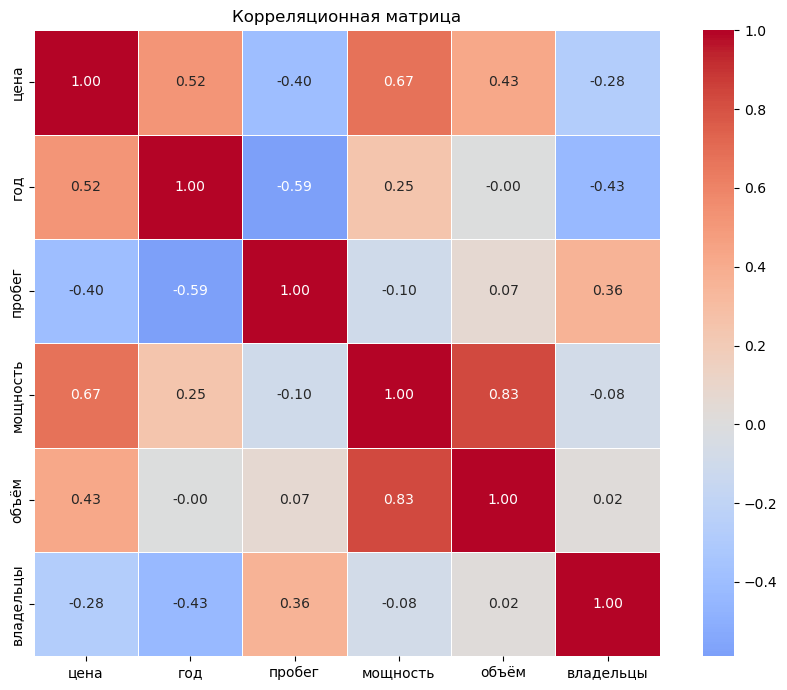

Корреляция признаков с ценой (по убыванию |r|):
мощность     0.675
год          0.519
объём        0.427
пробег      -0.399
владельцы   -0.277
Name: цена, dtype: float64


In [43]:
# Связи между признаками

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Расчёт корреляционной матрицы (нужен для heatmap ниже)
corr = df[['цена', 'год', 'пробег', 'мощность', 'объём', 'владельцы']].corr(numeric_only=True)

# 1. Цена vs Год (boxplot)
ax = axes[0, 0]
data = df[(df['цена'] > 0) & (df['цена'] < 15_000_000) &
          (df['год'] >= 2000) & (df['год'] <= 2026)]
sns.boxplot(data=data, x='год', y='цена', ax=ax, color='skyblue')
ax.set_title('Цена по годам выпуска')
ax.set_xlabel('Год')
ax.set_ylabel('Цена, руб.')
ax.tick_params(axis='x', rotation=90)

# 2. Цена vs Пробег (scatter)
ax = axes[0, 1]
data = df[(df['цена'] > 0) & (df['цена'] < 15_000_000) &
          (df['пробег'] > 0) & (df['пробег'] < 500_000)]
ax.scatter(data['пробег'], data['цена'], alpha=0.2, s=8, c='crimson')
ax.set_title('Цена vs Пробег')
ax.set_xlabel('Пробег, км')
ax.set_ylabel('Цена, руб.')

# 3. Цена vs Мощность (scatter)
ax = axes[1, 0]
data = df[(df['цена'] > 0) & (df['цена'] < 15_000_000) &
          (df['мощность'] > 0) & (df['мощность'] < 500)]
ax.scatter(data['мощность'], data['цена'], alpha=0.2, s=8, c='darkgreen')
ax.set_title('Цена vs Мощность')
ax.set_xlabel('Мощность, л.с.')
ax.set_ylabel('Цена, руб.')

# 4. Медианная цена по маркам (топ-15)
ax = axes[1, 1]
top_brands = df['марка'].value_counts().head(15).index
median_price = (df[df['марка'].isin(top_brands)]
                .groupby('марка')['цена'].median()
                .sort_values())
ax.barh(median_price.index, median_price.values,
        color='darkorange', edgecolor='black')
ax.set_title('Медианная цена — топ-15 марок')
ax.set_xlabel('Цена, руб.')

plt.tight_layout()
plt.show()

# Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

# Текстовый вывод корреляций с целевой переменной
print("Корреляция признаков с ценой (по убыванию |r|):")
price_corr = corr['цена'].drop('цена').sort_values(key=lambda x: abs(x), ascending=False)
print(price_corr.round(3))

Из графиков можно сделать следующие выводы

1. Цена vs год
   - Чёткий тренд: чем новее, тем дороже
   - Разброс цен растёт с годом — у свежих машин диапазон шире
   - Много выбросов 2018–2023 — это премиум-сегмент (BMW, Mercedes,
     Lexus), а не ошибки данных
   - Медиана 2024–2026 заметно выше, чем у 2010–2015 (примерно в 2–3 раза)

2. Цена vs пробег
   - Обратная зависимость: больше пробег → ниже цена
   - Разброс огромный, значит пробег — не единственный фактор
   - Основная масса машин: 50–250 тыс км, цена до 3 млн
   - Есть «хвост» дорогих машин с большим пробегом — вероятно,
     премиум-внедорожники или плохо оценённые лоты

3. Цена vs мощность
   - Прямая зависимость: мощнее → дороже
   - Видны вертикальные полосы — стандартные мощности (150, 190,
     249, 300 л.с.) — типичный признак массового рынка
   - Связь с ценой самая сильная среди числовых признаков (r ≈ 0.67)

4. Распределение цены по маркам (boxplot, топ-15)
   - БМВ и Ауди — лидеры по медиане (~3.0 и ~2.5 млн соответственно)
   - У БМВ, Ауди, Тойоты широкий разброс — покрывают разные сегменты
     (от старых моделей до свежего премиума)
   - LADA — на дне (~500 тыс), коробочка узкая: почти все машины
     в диапазоне 300–700 тыс
   - Разрыв между лидером (BMW) и аутсайдером (LADA) — примерно 6 раз
   - Ниссан, Мазда, Рено — плотные, узкие распределения (однородный
     бюджетный/средний сегмент)

5. Корреляционная матрица (heatmap)
   - Самая сильная связь с ценой: мощность (0.67)
   - Далее: год (0.52), объём (0.43)
   - Обратные связи: пробег (−0.40), владельцы (−0.28)
   - Мощность и объём сильно связаны между собой (0.83) —
     мультиколлинеарность, но для CatBoost это не проблема
   - Год и пробег связаны (−0.59): новые машины в среднем меньше ездят
   - Владельцы и год тоже связаны (−0.43): у старых машин больше
     хозяев — это логично и подтверждает корректность данных

## Статистический анализ и проверка гипотез

Корреляционный анализ показал силу связи признаков с ценой, но не
ответил на вопрос, значимы ли эти связи статистически. Проведём
формальные тесты для четырёх гипотез:

1. Правый руль влияет на цену (t-тест).
2. Тип привода связан с ценовым сегментом (χ²-тест).
3. Год выпуска значимо коррелирует с ценой (корреляция с p-value).
4. Пробег значимо коррелирует с ценой (корреляция с p-value).

In [49]:
from scipy import stats

In [50]:
# Гипотеза 1: правый руль влияет на цену
# H0: средняя цена машин с правым и левым рулём одинакова
# H1: средняя цена отличается

left = df[df['руль'] == 'левый']['цена']
right = df[df['руль'] == 'правый']['цена']

t_stat, p_value = stats.ttest_ind(left, right, equal_var=False)

print("Гипотеза 1: правый руль vs левый")
print(f"Средняя цена (левый):  {left.mean():,.0f} руб. (n={len(left)})")
print(f"Средняя цена (правый): {right.mean():,.0f} руб. (n={len(right)})")
print(f"t-статистика: {t_stat:.3f}")
print(f"p-value:      {p_value:.2e}")
print()
if p_value < 0.05:
    print("Вывод: различие статистически значимо (p < 0.05). Гипотеза H0 отвергается.")
else:
    print("Вывод: различие незначимо (p >= 0.05). H0 не отвергается.")

Гипотеза 1: правый руль vs левый
Средняя цена (левый):  1,869,398 руб. (n=3205)
Средняя цена (правый): 1,380,190 руб. (n=712)
t-статистика: 7.812
p-value:      8.75e-15

Вывод: различие статистически значимо (p < 0.05). Гипотеза H0 отвергается.


In [51]:
# Гипотеза 2: тип привода связан с ценовым сегментом
# H0: привод и сегмент независимы
# H1: связь есть

# Разбиваем цены на сегменты
df['сегмент'] = pd.cut(
    df['цена'],
    bins=[0, 1_000_000, 3_000_000, 100_000_000],
    labels=['бюджет', 'средний', 'премиум']
)

# Таблица сопряжённости
contingency = pd.crosstab(df['привод'], df['сегмент'])
print("Таблица сопряжённости:")
print(contingency)
print()

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"χ²-статистика: {chi2:.3f}")
print(f"Степени свободы: {dof}")
print(f"p-value: {p_value:.2e}")
print()
if p_value < 0.05:
    print("Вывод: связь статистически значима (p < 0.05). Привод и сегмент связаны.")
else:
    print("Вывод: связь незначима (p >= 0.05).")

Таблица сопряжённости:
сегмент     бюджет  средний  премиум
привод                              
4WD            274      715      490
задний         111       65       10
неизвестно       5        5        0
передний      1487      794       50

χ²-статистика: 1094.820
Степени свободы: 6
p-value: 2.75e-233

Вывод: связь статистически значима (p < 0.05). Привод и сегмент связаны.


In [52]:
# Гипотеза 3: год значимо коррелирует с ценой
# Используем коэффициент Спирмена (устойчив к выбросам и нелинейности)

rho, p_value = stats.spearmanr(df['год'], df['цена'])

print("Гипотеза 3: корреляция год ↔ цена")
print(f"Коэффициент Спирмена: {rho:.3f}")
print(f"p-value: {p_value:.2e}")
print()
if p_value < 0.05:
    print(f"Вывод: корреляция значима. Знак {'+' if rho > 0 else '-'}.")
else:
    print("Вывод: корреляция незначима.")

Гипотеза 3: корреляция год ↔ цена
Коэффициент Спирмена: 0.728
p-value: 0.00e+00

Вывод: корреляция значима. Знак +.


In [53]:
# Гипотеза 4: пробег значимо коррелирует с ценой
# Убираем NaN в пробеге

df_probeg = df.dropna(subset=['пробег'])
rho, p_value = stats.spearmanr(df_probeg['пробег'], df_probeg['цена'])

print("Гипотеза 4: корреляция пробег ↔ цена")
print(f"Коэффициент Спирмена: {rho:.3f}")
print(f"p-value: {p_value:.2e}")
print()
if p_value < 0.05:
    print(f"Вывод: корреляция значима. Знак {'+' if rho > 0 else '-'}.")
else:
    print("Вывод: корреляция незначима.")

Гипотеза 4: корреляция пробег ↔ цена
Коэффициент Спирмена: -0.471
p-value: 2.31e-210

Вывод: корреляция значима. Знак -.


## Выводы по статистическим тестам

Все четыре гипотезы подтвердились на уровне значимости p < 0.05.
Это означает, что закономерности, замеченные визуально в EDA,
статистически значимы, а не случайны.

### 1. Правый руль vs левый
- Средняя цена левого руля: 1,869,398 руб. (n=3205)
- Средняя цена правого руля: 1,380,190 руб. (n=712)
- t-статистика = 7.81, p-value = 8.75e-15

**Вывод:** различие статистически значимо. Машины с правым рулём
в среднем дешевле левого на ~490 тыс. руб. Это ожидаемо —
правый руль ограничивает географию продажи (в основном Дальний
Восток и Сибирь) и сужает круг покупателей.

### 2. Привод vs ценовой сегмент
Таблица сопряжённости:

| Привод | Бюджет | Средний | Премиум |
|---|---|---|---|
| 4WD | 274 | 715 | 490 |
| задний | 111 | 65 | 10 |
| передний | 1487 | 794 | 50 |
| неизвестно | 5 | 5 | 0 |

χ² = 1094.8, df = 6, p-value = 2.75e-233

**Вывод:** связь привода и ценового сегмента сверхсильная.
Видно: передний привод доминирует в бюджете (1487 машин),
4WD — в среднем и премиум-сегментах, задний — редкий,
преимущественно в бюджете. 

### 3. Год выпуска ↔ цена (корреляция Спирмена)
- Коэффициент = 0.728, p-value < 0.001

**Вывод:** положительная значимая связь. Чем новее машина,
тем она дороже. Коэффициент Спирмена (0.728) заметно выше
коэффициента Пирсона (0.52) — значит, связь **нелинейная**,
но монотонная: с каждым годом цена растёт ускоряюще.
Это подтверждает, что деревья решений (CatBoost) подходят
лучше линейных моделей.

### 4. Пробег ↔ цена (корреляция Спирмена)
- Коэффициент = −0.471, p-value < 0.001

**Вывод:** отрицательная значимая связь. Чем больше пробег,
тем дешевле машина. Связь слабее, чем у года, но всё равно
устойчивая.

### Итоговый вывод
Все четыре гипотезы подтвердились. Закономерности, выявленные
в EDA, статистически значимы:

- **год** — основной положительный фактор (+0.728)
- **мощность** — второй по силе (по Пирсону +0.67)
- **пробег** — значимый отрицательный фактор (−0.471)
- **правый руль** — снижает цену на ~490 тыс. руб.
- **привод** — тесно связан с сегментом (4WD чаще в премиуме)

Это даёт уверенность в выборе признаков для ML-модели: все они
несут реальный сигнал, а не случайный шум.

In [45]:
# Анализ выбросов и аномалий

print("-" * 70)
print("1. Дорогие машины (цена > 15 млн)")
print("-" * 70)
expensive = df[df['цена'] > 15_000_000].sort_values('цена', ascending=False)
print(f"Всего: {len(expensive)} шт.\n")
print(expensive[['марка', 'модель', 'год', 'цена', 'мощность', 'пробег']].head(15).to_string())

print("\nМарки в дорогом сегменте:")
print(expensive['марка'].value_counts().head(10))

print("\n" + "-" * 70)
print("2. Мощные машины (мощность > 500 л.с.)")
print("-" * 70)
powerful = df[df['мощность'] > 500].sort_values('мощность', ascending=False)
print(f"Всего: {len(powerful)} шт.\n")
print(powerful[['марка', 'модель', 'год', 'мощность', 'цена']].to_string())

print("\n" + "-" * 70)
print("3. Дешёвые машины (цена < 50 000 руб.)")
print("-" * 70)
cheap = df[df['цена'] < 50_000].sort_values('цена')
print(f"Всего: {len(cheap)} шт.\n")
print(cheap[['марка', 'модель', 'год', 'цена', 'пробег', 'мощность']].to_string())

print("\n" + "-" * 70)
print("4. Аномально новые (год 2026)")
print("-" * 70)
future = df[df['год'] == 2026]
print(f"Всего: {len(future)} шт.\n")
print("Марки:")
print(future['марка'].value_counts().head(10))
print(f"\nМедианная цена: {future['цена'].median():,.0f}")
print(f"Медианный пробег: {future['пробег'].median():,.0f}")

print("\n" + "-" * 70)
print("5. Экстремальный пробег (> 500 000 км)")
print("-" * 70)
old_miles = df[df['пробег'] > 500_000].sort_values('пробег', ascending=False)
print(f"Всего: {len(old_miles)} шт.\n")
print(old_miles[['марка', 'модель', 'год', 'пробег', 'цена']].head(10).to_string())

----------------------------------------------------------------------
1. Дорогие машины (цена > 15 млн)
----------------------------------------------------------------------
Всего: 31 шт.

         марка     модель   год      цена  мощность  пробег
2719  Мерседес    S-Класс  2026  33400000     537.0     NaN
2722  Мерседес    S-Класс  2026  28840000     367.0     NaN
2644       БМВ         Х7  2026  18750000     381.0     NaN
2650       БМВ         Х7  2026  18500000     352.0     NaN
2645       БМВ         Х7  2026  17700000     352.0     NaN
2653       БМВ         Х7  2025  17500000     381.0     NaN
1899  Инфинити  Ку Икс 80  2025  16990000     450.0    20.0
2630       БМВ         Х6  2026  16990000     298.0     NaN
1910  Инфинити  Ку Икс 80  2025  16990000     450.0    20.0
2617       БМВ         Х6  2025  16380000     298.0  5000.0
1893  Инфинити  Ку Икс 80  2026  16290000     450.0    32.0
1902  Инфинити  Ку Икс 80  2026  16290000     450.0    34.0
1310    Тойота    Секвойя  20

Общие выводы по EDA

1. Общая характеристика датасета
   - 4006 объявлений с Drom.ru
   - 39 марок, 175 моделей
   - 548 уникальных городов, но распределение неравномерное:
     в топ-10 (Москва, Новосибирск, СПб и др.) — около 33% объявлений
   - Пропуски: владельцы — 35%, пробег — 4%, объём — 1.2%
   - Пустой столбец «кузов» удалён (данные не спарсились)

2. Целевая переменная (цена)
   - Минимум: 10 000 руб.
   - Q1: 600 000 руб.
   - Медиана: 1 113 500 руб.
   - Q3: 1 950 000 руб.
   - Максимум: 33 400 000 руб.
   - Среднее: 1 747 324 руб.
   Среднее больше медианы в 1.6 раза — распределение скошено
   вправо, есть длинный хвост из дорогих машин. Из-за этого
   для оценки модели логично взять MAE, а не RMSE — она меньше
   реагирует на выбросы.

3. Числовые признаки
   - Год: медиана 2013, диапазон 1975–2026, основная масса 2005–2021
   - Пробег: медиана 165 тыс км, распределение с длинным хвостом вправо
   - Мощность: медиана 140 л.с., заметны два пика — около 110 и 150 л.с.
   - Объём: медиана 1.8 л, основные значения — 1.6 и 2.0 л

4. Категориальные признаки
   - Топливо: бензин 86%, дизель 8%, гибрид 5%, электро 1%
   - Коробка: АКПП 47%, механика 28%, вариатор 17%, робот 7%
   - Привод: передний 58%, 4WD 37%, задний 5%
   - Руль: левый 80%, правый 18%
   - Топ-5 марок: Тойота, LADA, Ниссан, Хендай, Киа

5. Связи с ценой (корреляции)
   - Мощность: +0.67
   - Год: +0.52
   - Объём: +0.43
   - Пробег: −0.40
   - Владельцы: −0.28
   Между признаками тоже есть связи: мощность и объём (0.83),
   год и пробег (−0.59), год и владельцы (−0.43). Это значит,
   что признаки частично дублируют друг друга по смыслу, но для
   будущей модели это не критично.

6. Для будущей ML
   - Самые сильные связи с ценой — у мощности, года и объёма
   - Владельцы дают более слабый, но заметный сигнал (−0.28)
   - Числовые пропуски CatBoost обрабатывает сам
   - Категориальные признаки передать как cat_features
   - NaN в категориальных лучше явно заменить на 'неизвестно'

7. Выбросы и аномалии (посмотрел вручную)

   Дорогие (>15 млн) — 31 шт.
   Все — реальные премиум-машины: Mercedes S-Класс, BMW X7,
   Infiniti QX80, Toyota Sequoia, Audi. Года 2025–2026, пробег
   почти нулевой или не указан. Это валидный сегмент, а не ошибки.

   Мощные (>500 л.с.) — 10 шт.
   Реальные спорткары (Mercedes AMG, BMW M-серия). Интересно,
   что у старых моделей цена падает сильнее, чем можно было бы
   ожидать по мощности: например, Mercedes S-Класс 2006 с 517 л.с.
   стоит всего 1.2 млн.

   Дешёвые (<50 тыс) — 7 шт.
   Старые LADA 2107/2115, Audi A4 2003, Nissan Sunny 1998.
   Валидные машины, часть реального рынка.

   Год 2026 — 145 шт.
   Медианный пробег 18 км, медианная цена 4.3 млн.
   Похоже на предзаказы или новые машины с нулевым пробегом.
   Встречаются у всех марок (LADA, Тойота, Ауди, Фольксваген
   и т.д.), значит это не ошибка парсинга.

   Пробег >500 тыс — 15 шт.
   Реальные «уставшие» авто: Рено Сандеро 2011 (700 тыс км),
   Тойота Ярис 2000 (692 тыс км), Nissan Almera 2017 (553 тыс).
   Часть — вероятно, бывшие такси.
   Машины с пробегом >800 тыс (2 шт.) удалил на этапе чистки.

   По итогу: серьёзных ошибок в выбросах не нашёл. Всё, что
   выглядит странно, — это реальные машины, а не мусор в данных.
   Ничего удалять не стал.

8. Наблюдения для ML-модели
   - NaN в пробеге часто встречается у машин 2025–2026 годов.
     Возможно, модель сама поймает эту связь, но стоит проверить
     по важности признаков после обучения.
   - Мощность важна, но не отменяет возраст: Mercedes S-Класс 2006
     с 517 л.с. стоит 1.2 млн, а BMW X5 2023 с 530 л.с. — 13 млн.
     При похожей мощности разница больше чем в 10 раз.
   - 145 машин 2026 года — отдельный сегмент (новые с нулевым
     пробегом, медиана 4.3 млн). Оставить как есть.
   - 40 электромобилей — редкая категория топлива, оставить.
   - Категориальные признаки для CatBoost: марка, модель, коробка,
     привод, руль, топливо, город, поколение, комплектация.

In [46]:
# Сохраняем обработанный датасет для ML
df.to_csv('../data/processed/cars_clean.csv', index=False)
print(f"Сохранено: {len(df)} строк, {df.shape[1]} колонок")
print(f"Колонки: {df.columns.tolist()}")

Сохранено: 4006 строк, 21 колонок
Колонки: ['url', 'ad_id', 'марка_модель', 'цена', 'год', 'двигатель', 'мощность', 'коробка', 'привод', 'цвет', 'пробег', 'владельцы', 'руль', 'поколение', 'комплектация', 'город', 'объём', 'топливо', 'гбо', 'марка', 'модель']


In [48]:
import os
os.makedirs('../data/processed', exist_ok=True)

df.to_csv('../data/processed/cars_clean.csv', index=False)
print(f"Сохранено {len(df)} строк, {df.shape[1]} колонок")
print(f"Колонки: {df.columns.tolist()}")

Сохранено 4006 строк, 21 колонок
Колонки: ['url', 'ad_id', 'марка_модель', 'цена', 'год', 'двигатель', 'мощность', 'коробка', 'привод', 'цвет', 'пробег', 'владельцы', 'руль', 'поколение', 'комплектация', 'город', 'объём', 'топливо', 'гбо', 'марка', 'модель']
